# SECOM Semiconductor Yield Prediction

## 1. Data Loading

The SECOM dataset contains 1567 production units, each described by 591 sensor measurements. The target variable indicates whether a unit passed (-1) or failed (1) in-house line testing. With only 104 failures (~6.6%), the dataset exhibits severe class imbalance.

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

base_dir = os.path.expanduser('~/Documents/semiconductor-yield-prediction')

X = pd.read_csv(os.path.join(base_dir, 'data/secom.data'), sep=' ', header=None)
labels = pd.read_csv(os.path.join(base_dir, 'data/secom_labels.data'), sep=' ', header=None, names=['label', 'timestamp'])
y = labels['label']

print("Feature matrix shape:", X.shape)
print("Label shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())
print(f"\nFail rate: {(y == 1).sum() / len(y) * 100:.1f}%")

Feature matrix shape: (1567, 590)
Label shape: (1567,)

Class distribution:
label
-1    1463
 1     104
Name: count, dtype: int64

Fail rate: 6.6%


## 2. Exploratory Data Analysis

### 2.1 Missing Value Analysis

538 out of 590 sensors have at least one missing value. The missingness distribution is bimodal (most sensors are nearly complete), with a small cluster around 15-20% and another group above 60%. We cut at 20%, which aligns with the natural gap in 
the distribution rather than an arbitrary threshold.

Features with any missing values: 538
Features with >10% missing: 52
Features with >20% missing: 32
Features with >50% missing: 28


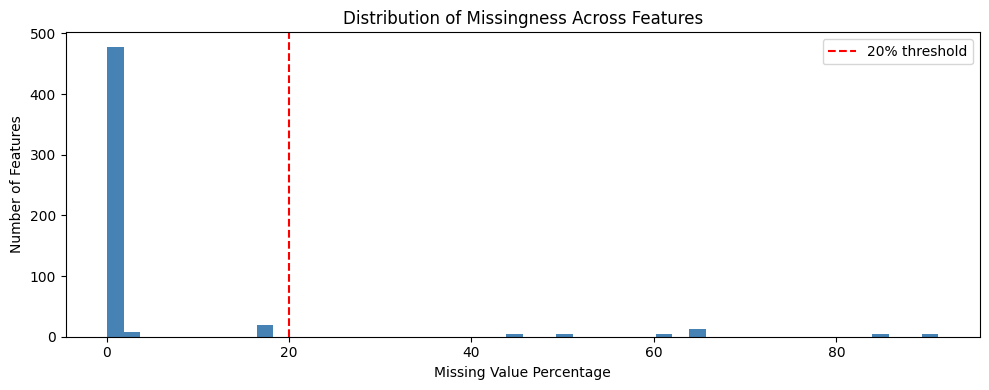

In [3]:
# Calculate missing value percentage per feature
missing_pct = (X.isna().sum() / len(X)) * 100

print(f"Features with any missing values: {(missing_pct > 0).sum()}")
print(f"Features with >10% missing: {(missing_pct > 10).sum()}")
print(f"Features with >20% missing: {(missing_pct > 20).sum()}")
print(f"Features with >50% missing: {(missing_pct > 50).sum()}")

# Plot distribution of missingness
plt.figure(figsize=(10, 4))
plt.hist(missing_pct[missing_pct > 0], bins=50, color='steelblue')
plt.xlabel('Missing Value Percentage')
plt.ylabel('Number of Features')
plt.title('Distribution of Missingness Across Features')
plt.axvline(20, color='red', linestyle='--', label='20% threshold')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'reports/missing_values.png'), dpi=150)
plt.show()

### 2.2 Class Imbalance

Only 104 of 1567 units are failures (~6.6%), creating severe class imbalance. 
A naive model predicting "pass" for every unit would achieve 93.4% accuracy while 
catching zero failures, making accuracy a misleading metric. We will use Balanced 
Error Rate (BER) and precision-recall curves throughout.

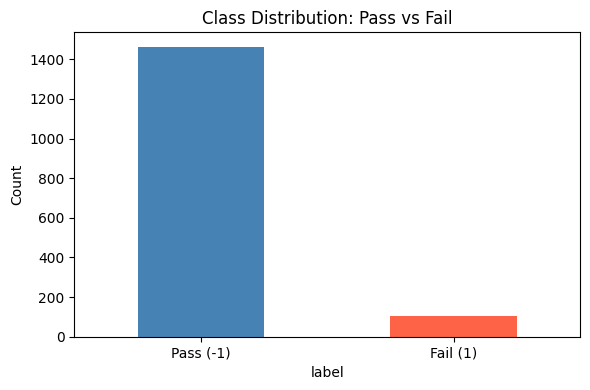

In [4]:
plt.figure(figsize=(6, 4))
y.value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.xticks([0, 1], ['Pass (-1)', 'Fail (1)'], rotation=0)
plt.ylabel('Count')
plt.title('Class Distribution: Pass vs Fail')
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'reports/class_distribution.png'), dpi=150)
plt.show()

## 3. Preprocessing

Before modeling we need to clean the data in three steps:
1. Drop sensors with >20% missing values
2. Drop constant sensors (sensors that never change carry no predictive information)
3. Impute remaining missing values using column medians
4. Convert labels from -1/1 to 0/1 for compatibility with sklearn and PyTorch

In [5]:
from sklearn.impute import SimpleImputer

# Drop high missingness features
high_missing = missing_pct[missing_pct > 20].index
X_clean = X.drop(columns=high_missing)
print(f"After dropping >20% missing: {X_clean.shape[1]} features")

# Drop constant features
constant_features = X_clean.columns[X_clean.nunique() <= 1]
X_clean = X_clean.drop(columns=constant_features)
print(f"After dropping constant features: {X_clean.shape[1]} features")

# Impute remaining missing values with column median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_clean), columns=X_clean.columns)
print(f"Any remaining missing values: {X_imputed.isna().any().any()}")

# Convert labels from -1/1 to 0/1
y_binary = (y == 1).astype(int)
print(f"\nFinal dataset shape: {X_imputed.shape}")
print(f"Label distribution:\n{y_binary.value_counts()}")

After dropping >20% missing: 558 features
After dropping constant features: 442 features
Any remaining missing values: False

Final dataset shape: (1567, 442)
Label distribution:
label
0    1463
1     104
Name: count, dtype: int64


## 4. Baseline Model: Logistic Regression

We establish a baseline using logistic regression, the simplest linear classifier. All subsequent models must beat this baseline to justify their added complexity. We use stratified k-fold cross validation to match the evaluation approach from the original UCI paper.

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import balanced_accuracy_score, make_scorer
import warnings
warnings.filterwarnings('ignore')

# Set every sensor to have mean=0 and standard deviation=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# Stratified 10-fold cross validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=23)

# Balanced accuracy = 1 - BER, so we can compare to the UCI paper
scorer = make_scorer(balanced_accuracy_score)

# Fit logistic regression with class_weight='balanced' to handle imbalance
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=23)
results = cross_validate(lr, X_scaled, y_binary, cv=cv, scoring=scorer)

balanced_acc = results['test_score'].mean()
ber = 1 - balanced_acc

print(f"Logistic Regression (baseline)")
print(f"Balanced Accuracy: {balanced_acc:.3f} (+/- {results['test_score'].std():.3f})")
print(f"BER: {ber*100:.1f}%")
print(f"\nUCI paper best baseline BER: 33.5%")
print(f"Our BER: {ber*100:.1f}%")

Logistic Regression (baseline)
Balanced Accuracy: 0.602 (+/- 0.073)
BER: 39.8%

UCI paper best baseline BER: 33.5%
Our BER: 39.8%


## 5. Feature Selection

With 442 features and only 1567 samples we are in a high dimensional regime where 
most features add noise rather than signal. We apply three complementary feature 
selection methods and compare their impact on BER:

1. **Univariate selection (F-test)** — ranks each feature independently by its 
   statistical relationship with the label. Direct comparison to UCI baseline.
2. **L1 Regularization (LASSO)** — penalizes the model for using too many features, 
   automatically shrinking irrelevant ones to zero.
3. **Tree-based importance (Random Forest)** — ranks features by how useful they 
   were across an ensemble of decision trees.

k=20: BER=30.4%
k=40: BER=34.0%
k=60: BER=33.8%
k=80: BER=36.5%
k=100: BER=35.9%
k=150: BER=40.0%
k=200: BER=41.2%


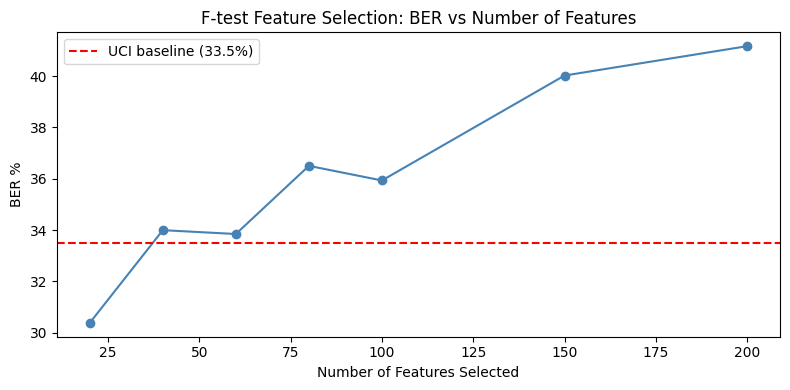

In [7]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import numpy as np

# We'll test multiple values of k to find the optimal number of features
k_values = [20, 40, 60, 80, 100, 150, 200]
ftest_bers = []

for k in k_values:
    selector = SelectKBest(f_classif, k=k)
    lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
    pipe = Pipeline([('select', selector), ('classify', lr)])
    results = cross_validate(pipe, X_scaled, y_binary, cv=cv, scoring=scorer)
    ber = 1 - results['test_score'].mean()
    ftest_bers.append(ber)
    print(f"k={k}: BER={ber*100:.1f}%")

# Plot BER vs number of features
plt.figure(figsize=(8, 4))
plt.plot(k_values, [b*100 for b in ftest_bers], marker='o', color='steelblue')
plt.axhline(33.5, color='red', linestyle='--', label='UCI baseline (33.5%)')
plt.xlabel('Number of Features Selected')
plt.ylabel('BER %')
plt.title('F-test Feature Selection: BER vs Number of Features')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'reports/ftest_selection.png'), dpi=150)
plt.show()

### 5.1 F-test Results

F-test feature selection with k=20 achieves BER=30.4%, beating the UCI paper baseline of 33.5% which used k=40. Performance degrades steadily beyond k=20, confirming that the majority of the 442 remaining features contain noise rather than signal. This suggests the true predictive information in this dataset is concentrated in a small subset of sensors.